# FLAMES 30 Dor — composition-preserving synthetic training sample

This notebook replaces the previous independent-component bootstrap with a recipe-level generator.

Main changes:
1. Accept Stage A runs by reduced chi-square, but also remove duplicate manual runs.
2. Build a component table with physical sanity filters.
3. Classify components into narrow/broad families using FWHM in wavelength units.
4. Preserve empirical spectrum compositions, e.g. `(2 narrow, 1 broad)`, instead of sampling `ncomp` and components independently.
5. Generate GaussPy-compatible training data.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STAGE_A_FILE = "stageA_results.pkl"
FILENAME_TRAIN = "flames30dor_training_data_composition_03.pkl"

RNG_SEED = 123
rng = np.random.default_rng(RNG_SEED)

with open(STAGE_A_FILE, "rb") as f:
    results = pickle.load(f)

print("Stage A runs:", len(results))
print(results[0].keys())


Stage A runs: 41
dict_keys(['object', 'filename', 'sample', 'index', 'wmin', 'wmax', 'phase', 'alpha1', 'snr_thresh', 'wave', 'flux', 'err', 'means_initial', 'amps_initial', 'fwhms_initial', 'ncomp_initial', 'means_fit', 'amps_fit', 'fwhms_fit', 'ncomp_fit', 'means_fit_err', 'amps_fit_err', 'fwhms_fit_err', 'best_fit_rchi2', 'notes'])


In [3]:
def to_1d_array(x):
    arr = np.asarray(x, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def scalar_rchi2(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        if len(x) == 0:
            return np.nan
        return float(np.asarray(x).ravel()[0])
    return float(x)

# First-pass accepted runs
accepted = []

for i, r in enumerate(results):
    rchi2 = scalar_rchi2(r["best_fit_rchi2"])
    ncomp = int(r["ncomp_fit"])

    if ncomp > 0 and np.isfinite(rchi2) and rchi2 < 20:
        rr = dict(r)
        rr["_stageA_index"] = i
        rr["_rchi2_scalar"] = rchi2
        accepted.append(rr)

print("Accepted before duplicate removal:", len(accepted))

# Remove exact duplicate manual runs.
# For this Stage A file, t36 appears twice with identical metadata and rchi2.
seen = set()
accepted_unique = []

for r in accepted:
    key = (
        r.get("object"),
        r.get("sample"),
        r.get("index"),
        r.get("filename"),
        int(r.get("ncomp_fit")),
        round(float(r["_rchi2_scalar"]), 8),
    )
    if key not in seen:
        accepted_unique.append(r)
        seen.add(key)

accepted = accepted_unique
print("Accepted after duplicate removal:", len(accepted))


Accepted before duplicate removal: 29
Accepted after duplicate removal: 29


In [4]:
rows = []

for spec_id, r in enumerate(accepted):
    wave = to_1d_array(r["wave"])
    err = to_1d_array(r["err"])
    amps = to_1d_array(r["amps_fit"])
    fwhms = to_1d_array(r["fwhms_fit"])
    means = to_1d_array(r["means_fit"])

    if len(wave) < 2:
        continue

    dw = float(np.nanmedian(np.diff(wave)))
    w0 = float(np.nanmin(wave))
    w1 = float(np.nanmax(wave))
    rms = float(np.nanmedian(err))
    nchannels = len(wave)

    n = min(len(amps), len(fwhms), len(means))

    for j in range(n):
        rows.append({
            "spec_id": spec_id,
            "stageA_index": r["_stageA_index"],
            "object": r.get("object"),
            "sample": r.get("sample"),
            "index": r.get("index"),
            "filename": r.get("filename"),
            "notes": r.get("notes"),
            "rchi2": r["_rchi2_scalar"],
            "j": j,
            "amp": float(amps[j]),
            "fwhm_nm": float(fwhms[j]),
            "mean_nm": float(means[j]),
            "fwhm_chan": float(fwhms[j] / dw),
            "mean_chan": float((means[j] - w0) / dw),
            "dw": dw,
            "rms": rms,
            "nchannels": nchannels,
            "wave_min": w0,
            "wave_max": w1,
        })

comp_df_raw = pd.DataFrame(rows)
print("Raw accepted components:", len(comp_df_raw))
comp_df_raw[["amp", "fwhm_nm", "fwhm_chan", "mean_nm", "mean_chan"]].describe()


Raw accepted components: 103


,amp,fwhm_nm,fwhm_chan,mean_nm,mean_chan
count,1.030000e+02,103.000000,103.000000,103.000000,103.000000
mean,8.775534e+05,3.327316,664.814017,660.584658,1015.506067
std,8.857761e+06,11.853557,2368.398538,18.999893,3796.271561
min,1.543207e+01,-0.072421,-14.470151,654.418417,-216.544579
25%,5.919053e+01,0.083200,16.623725,656.820469,263.397053
50%,8.070749e+02,0.130373,26.049199,656.873796,274.064280
75%,3.012453e+03,0.906788,181.180716,656.943752,288.035666
max,8.990108e+07,81.056851,16195.554249,777.604024,24396.552769


In [5]:
# Component-level sanity filters.
# These remove pathological GaussPy components that survived the spectrum-level rchi2 cut:
# - negative widths
# - components centered outside the extracted window
# - non-positive amplitudes
# Optional SNR cut can be activated later if needed.

comp_df = comp_df_raw[
    (comp_df_raw["amp"] > 0) &
    (comp_df_raw["fwhm_nm"] > 0) &
    (comp_df_raw["mean_chan"] >= 0) &
    (comp_df_raw["mean_chan"] <= comp_df_raw["nchannels"] - 1)
].copy()

comp_df["amp_snr"] = comp_df["amp"] / comp_df["rms"]

print("Components after sanity filters:", len(comp_df))
print("Removed components:", len(comp_df_raw) - len(comp_df))

comp_df[["amp", "amp_snr", "fwhm_nm", "fwhm_chan", "mean_nm", "mean_chan"]].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)


Components after sanity filters: 94
Removed components: 9


,amp,amp_snr,fwhm_nm,fwhm_chan,mean_nm,mean_chan
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,2682.999162,769.618518,0.834341,166.705306,656.844229,268.150246
std,7259.355112,2020.124365,1.565844,312.863251,0.195020,38.965619
min,15.432067,4.209888,0.036898,7.372430,655.972063,93.893712
5%,17.749087,5.507292,0.064007,12.788992,656.485846,196.537770
10%,22.560114,6.472910,0.070053,13.996997,656.662131,231.764008
25%,69.565391,18.883880,0.082656,16.514972,656.818194,262.942584
50%,775.772993,230.328400,0.119687,23.913989,656.869646,273.228967
75%,2370.362378,721.538726,0.255718,51.093638,656.920889,283.470624
90%,6152.879910,1724.579239,3.878604,774.963980,656.988158,296.910727


width_class
narrow    74
broad     20
Name: count, dtype: int64


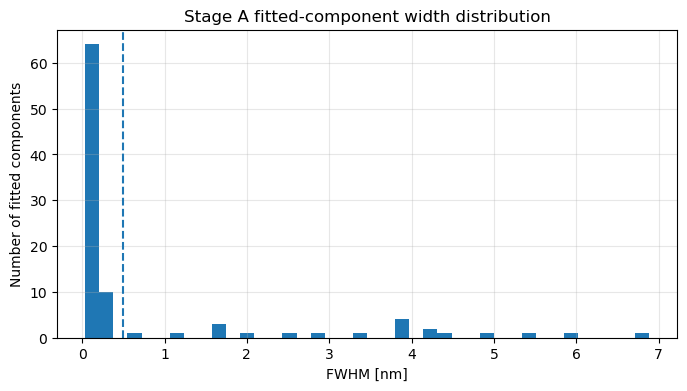

In [6]:
# IMPORTANT:
# The old notebook used broad_thresh = 12 in channel units.
# That is too low for these data because a typical narrow line has:
# FWHM ~ 0.08--0.15 nm and dw ~ 0.005 nm/channel,
# so narrow lines naturally have FWHM ~ 16--30 channels.
#
# A more interpretable first threshold is in wavelength units.
# Start with 0.5 nm. You can later tune this after visual inspection.

BROAD_FWHM_NM = 0.5

comp_df["width_class"] = np.where(
    comp_df["fwhm_nm"] >= BROAD_FWHM_NM,
    "broad",
    "narrow",
)

print(comp_df["width_class"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(comp_df["fwhm_nm"], bins=40)
plt.axvline(BROAD_FWHM_NM, linestyle="--")
plt.xlabel("FWHM [nm]")
plt.ylabel("Number of fitted components")
plt.title("Stage A fitted-component width distribution")
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
# Build empirical spectral recipes.
# Each recipe keeps the number of narrow and broad components per real accepted spectrum.

recipe_rows = []

for spec_id, sub in comp_df.groupby("spec_id"):
    n_narrow = int((sub["width_class"] == "narrow").sum())
    n_broad = int((sub["width_class"] == "broad").sum())

    if n_narrow + n_broad == 0:
        continue

    first = sub.iloc[0]

    recipe_rows.append({
        "spec_id": spec_id,
        "stageA_index": int(first["stageA_index"]),
        "object": first["object"],
        "sample": first["sample"],
        "index": first["index"],
        "notes": first["notes"],
        "rchi2": float(first["rchi2"]),
        "n_narrow": n_narrow,
        "n_broad": n_broad,
        "n_total": n_narrow + n_broad,
        "rms": float(first["rms"]),
        "nchannels": int(first["nchannels"]),
    })

recipe_df = pd.DataFrame(recipe_rows)

print("Number of empirical recipes:", len(recipe_df))
print("\nComposition counts:")
print(recipe_df.groupby(["n_narrow", "n_broad"]).size().sort_values(ascending=False))

recipe_df


Number of empirical recipes: 29

Composition counts:
n_narrow  n_broad
2         1          12
3         1           6
          0           3
4         0           3
1         1           2
2         0           2
5         0           1
dtype: int64


,spec_id,stageA_index,object,sample,index,notes,rchi2,n_narrow,n_broad,n_total,rms,nchannels
0,0,0,t02,W,75,clean single narrow,7.617132,2,1,3,2.942274,400
1,1,1,t03,W,72,clean single narrow,6.212939,2,1,3,3.288511,400
2,2,2,t15,W,89,clean single narrow,9.840241,2,1,3,3.336073,400
3,3,3,t18,W,25,clean single narrow,11.581230,2,0,2,4.108608,400
4,4,4,t28,W,95,clean single narrow,2.668885,3,1,4,3.207806,400
5,5,5,t35,W,48,clean single narrow,1.536450,3,0,3,3.159020,400
6,6,6,t40,W,31,clean single narrow,18.980989,2,1,3,3.719675,400
7,7,7,t44,W,100,clean single narrow,15.361185,3,1,4,3.610503,400
8,8,8,t12,W,49,single broad-dish,5.319352,2,1,3,3.216199,400
9,9,9,t36,W,88,single broad-dish,14.985296,1,1,2,3.269390,400


In [8]:
# Separate empirical component pools.
# The generator will sample a recipe first, then draw the requested number of
# narrow and broad components from the corresponding empirical pools.

narrow_pool = comp_df[comp_df["width_class"] == "narrow"].copy()
broad_pool = comp_df[comp_df["width_class"] == "broad"].copy()

print("Narrow pool:", len(narrow_pool))
print("Broad pool:", len(broad_pool))

print("\nNarrow FWHM [nm]:")
print(narrow_pool["fwhm_nm"].describe(percentiles=[0.05, 0.5, 0.95]))

print("\nBroad FWHM [nm]:")
print(broad_pool["fwhm_nm"].describe(percentiles=[0.05, 0.5, 0.95]))


Narrow pool: 74
Broad pool: 20

Narrow FWHM [nm]:
count    74.000000
mean      0.124800
std       0.065812
min       0.036898
5%        0.063422
50%       0.099638
95%       0.250382
max       0.352635
Name: fwhm_nm, dtype: float64

Broad FWHM [nm]:
count    20.000000
mean      3.459641
std       1.663987
min       0.676532
5%        1.114019
50%       3.876453
95%       5.972559
max       6.879546
Name: fwhm_nm, dtype: float64


In [9]:
def gaussian(amp, fwhm, mean):
    return amp * np.exp(-4.0 * np.log(2.0) * (x - mean)**2 / fwhm**2)

def draw_component(pool, rng, jitter=True):
    row = pool.sample(n=1, replace=True, random_state=int(rng.integers(0, 2**32 - 1))).iloc[0]

    amp = float(row["amp"])
    fwhm = float(row["fwhm_chan"])
    mean = float(row["mean_chan"])

    if jitter:
        # Small multiplicative/position jitter prevents exact clones while preserving realism.
        amp *= float(rng.lognormal(mean=0.0, sigma=0.15))
        fwhm *= float(rng.lognormal(mean=0.0, sigma=0.08))
        mean += float(rng.normal(loc=0.0, scale=2.0))

    return amp, fwhm, mean

def generate_one_spectrum(recipe_df, narrow_pool, broad_pool, rng, jitter=True):
    recipe = recipe_df.sample(
        n=1,
        replace=True,
        random_state=int(rng.integers(0, 2**32 - 1)),
    ).iloc[0]

    nchannels = int(recipe["nchannels"])
    rms = float(recipe["rms"])
    x = np.arange(nchannels, dtype=float)

    y = rng.normal(loc=0.0, scale=rms, size=nchannels)
    err = np.ones(nchannels, dtype=float) * rms

    amps, fwhms, means = [], [], []

    for _ in range(int(recipe["n_narrow"])):
        a, w, m = draw_component(narrow_pool, rng, jitter=jitter)
        y += a * np.exp(-4.0 * np.log(2.0) * (x - m)**2 / w**2)
        amps.append(a)
        fwhms.append(w)
        means.append(m)

    for _ in range(int(recipe["n_broad"])):
        a, w, m = draw_component(broad_pool, rng, jitter=jitter)
        y += a * np.exp(-4.0 * np.log(2.0) * (x - m)**2 / w**2)
        amps.append(a)
        fwhms.append(w)
        means.append(m)

    return x, y, err, amps, fwhms, means, recipe


In [10]:
NSPECTRA = 100

data_train = {
    "data_list": [],
    "x_values": [],
    "errors": [],
    "amplitudes": [],
    "fwhms": [],
    "means": [],
    "recipe": [],
}

for i in range(NSPECTRA):
    x, y, err, amps, fwhms, means, recipe = generate_one_spectrum(
        recipe_df,
        narrow_pool,
        broad_pool,
        rng,
        jitter=True,
    )

    data_train["data_list"].append(y)
    data_train["x_values"].append(x)
    data_train["errors"].append(err)
    data_train["amplitudes"].append(amps)
    data_train["fwhms"].append(fwhms)
    data_train["means"].append(means)
    data_train["recipe"].append({
        "n_narrow": int(recipe["n_narrow"]),
        "n_broad": int(recipe["n_broad"]),
        "source_spec_id": int(recipe["spec_id"]),
        "source_object": recipe["object"],
        "source_notes": recipe["notes"],
    })

with open(FILENAME_TRAIN, "wb") as f:
    pickle.dump(data_train, f)

print("Saved:", FILENAME_TRAIN)
print("Synthetic spectra:", len(data_train["data_list"]))


Saved: flames30dor_training_data_composition_03.pkl
Synthetic spectra: 100


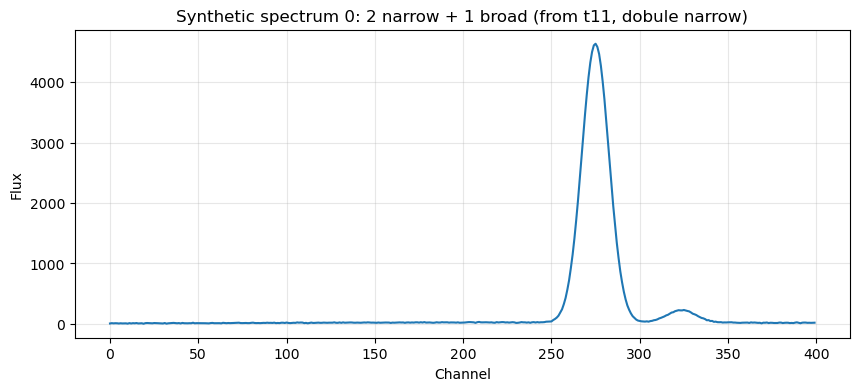

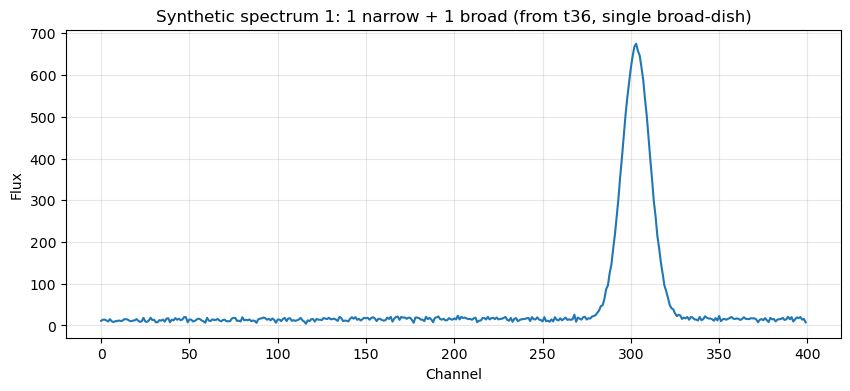

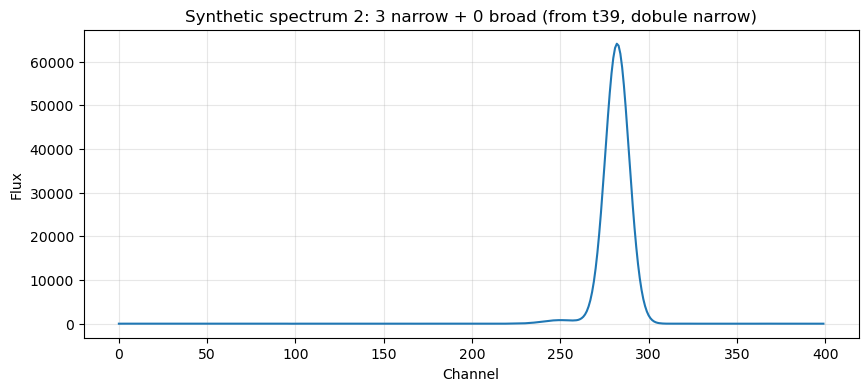

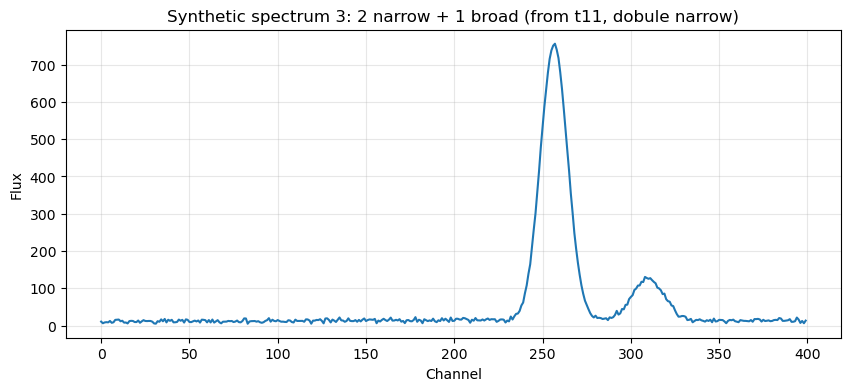

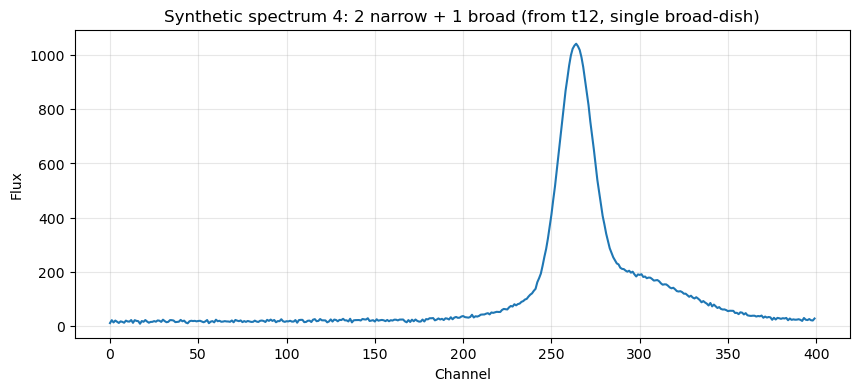

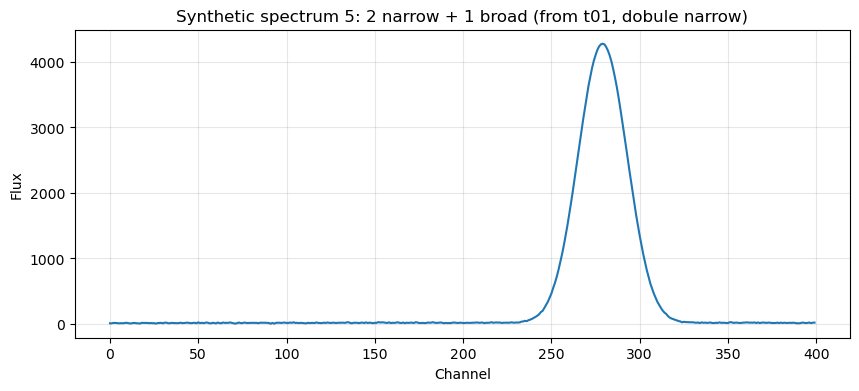

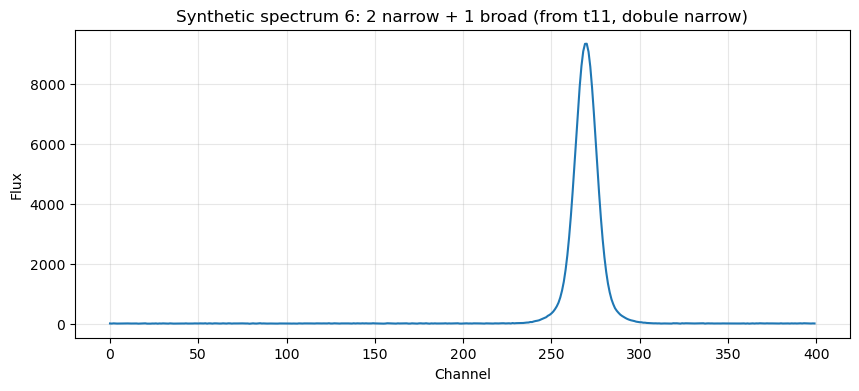

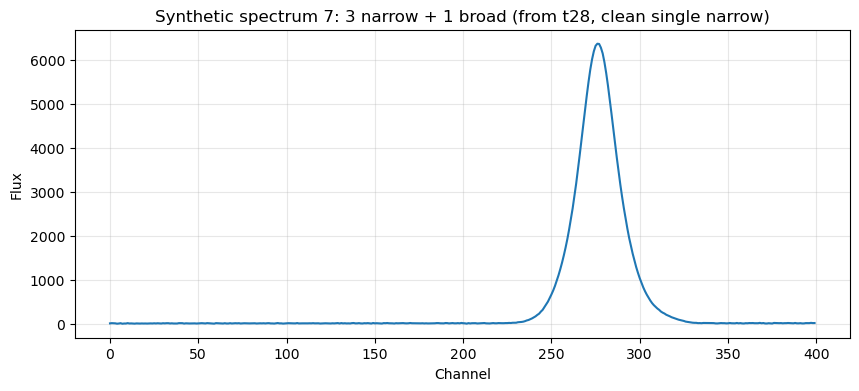

In [11]:
# Quick visual inspection.

nshow = min(8, NSPECTRA)

for i in range(nshow):
    plt.figure(figsize=(10, 4))
    plt.plot(data_train["x_values"][i], data_train["data_list"][i])
    recipe = data_train["recipe"][i]
    title = (
        f"Synthetic spectrum {i}: "
        f"{recipe['n_narrow']} narrow + {recipe['n_broad']} broad "
        f"(from {recipe['source_object']}, {recipe['source_notes']})"
    )
    plt.title(title)
    plt.xlabel("Channel")
    plt.ylabel("Flux")
    plt.grid(True, alpha=0.3)
    plt.show()


In [12]:
# Optional: inspect generated component counts.

synthetic_recipes = pd.DataFrame(data_train["recipe"])
print(synthetic_recipes.groupby(["n_narrow", "n_broad"]).size().sort_values(ascending=False))
synthetic_recipes.head()


n_narrow  n_broad
2         1          45
3         1          18
          0          11
4         0          11
1         1           9
2         0           5
5         0           1
dtype: int64


,n_narrow,n_broad,source_spec_id,source_object,source_notes
0,2,1,18,t11,dobule narrow
1,1,1,9,t36,single broad-dish
2,3,0,13,t39,dobule narrow
3,2,1,18,t11,dobule narrow
4,2,1,8,t12,single broad-dish


In [13]:

# import gausspy.gp as gp
#
# g = gp.GaussianDecomposer()
# g.load_training_data(FILENAME_TRAIN)
# g.set("phase", "two")
# g.set("SNR_thresh", [10, 10])
# g.train(alpha1_initial=0.5, alpha2_initial=2.0)
#
# print(g.p.get("alpha1"))
# print(g.p.get("alpha2"))
# print(g.p.get("training_results"))
